# BurstCube Data Types: CBD and TTE

BurstCube produces two primary time-series science data products for each of
its four detectors (`CS0`-`CS3`):

* **CBD** (continuous binned data): a pre-binned 16-channel time history of
  counts, nominally at 0.256 s resolution. Each observation day has an
  unfiltered (`_uf`) and a cleaned (`_cl`) version.
* **TTE** (time-tagged event data): an unbinned, 1024-channel photon list.
  Unlike GBM, BurstCube never had an onboard astrophysical trigger fire, so
  TTE exists only for 7 short commissioning/validation windows across the
  whole mission.

This notebook uses **2024-05-30** (`240530`) as the worked example, since it
is one of the 7 days with both CBD and TTE data, for detector `CS0`. It walks
through finding and downloading the data, `_uf` vs `_cl`, time selection,
rebinning, light curves, count spectra, and several of the caveats that
actually bite in practice.

Apart from the one section whose subject *is* the difference between the two
variants, every analysis here uses the cleaned (`_cl`) CBD.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gdt.core import data_path
from gdt.core.binning.binned import combine_by_factor
from gdt.core.binning.unbinned import bin_by_edges, bin_by_time
from gdt.core.plot.lightcurve import Lightcurve
from gdt.core.plot.spectrum import Spectrum

from gdt.missions.burstcube.cbd import BurstCubeCBD
from gdt.missions.burstcube.tte import BurstCubeTTE
from gdt.missions.burstcube.hk import BurstCubeHK
from gdt.missions.burstcube.finders import BurstCubeObsFinder
from gdt.missions.burstcube.gti import complement
from gdt.missions.burstcube import caldb

OBS_ID = '240530'
DETECTOR = 'CS0'
%matplotlib inline

## Finding and downloading a day

Every BurstCube archive filename is fully determined by the observation day,
detector, and product type, so `BurstCubeObsFinder` does not need to list a
remote directory to know what to download -- it just downloads the exact
files. Not every day has data: day directories are **not contiguous**, and
only 7 days out of the whole mission have TTE.

In [2]:
download_dir = Path(data_path) / 'burstcube' / OBS_ID
download_dir.mkdir(parents=True, exist_ok=True)

finder = BurstCubeObsFinder()
finder.cd(OBS_ID)
print('Contents of the day directory:', finder.files)

cbd_cl_path, = finder.get_cbd(download_dir, detectors=DETECTOR, variant='cl', verbose=False)
cbd_uf_path, = finder.get_cbd(download_dir, detectors=DETECTOR, variant='uf', verbose=False)
tte_path, = finder.get_tte(download_dir, detectors=DETECTOR, verbose=False)
hk_path = finder.get_hk(download_dir, verbose=False)

print('CBD (cl):', cbd_cl_path)
print('CBD (uf):', cbd_uf_path)
print('TTE:', tte_path)
print('Detector HK:', hk_path)

Contents of the day directory: ['auxil', 'events', 'monitor']


CBD (cl): /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_3cbd_cl.fits.gz
CBD (uf): /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_3cbd_uf.fits.gz
TTE: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_tte_uf.evt.gz
Detector HK: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530csa.hk.gz


## Opening CBD: `_uf` vs `_cl`

`_uf` is the unfiltered data as telemetered; `_cl` has bad/unphysical
intervals (captured in the GTIs) removed. Both are read the same way, with
`BurstCubeCBD.open()`.

In [3]:
cbd_uf = BurstCubeCBD.open(cbd_uf_path)
cbd_cl = BurstCubeCBD.open(cbd_cl_path)

print(cbd_uf)
print()
print(cbd_cl)

<BurstCubeCBD: bc240530cs0_3cbd_uf.fits.gz;
 time range (np.float64(107629262.94600001), np.float64(107654399.922));
 energy range (np.float64(0.0), np.float64(1648.510009765625))>

<BurstCubeCBD: bc240530cs0_3cbd_cl.fits.gz;
 time range (np.float64(107629263.202), np.float64(107634882.57));
 energy range (np.float64(0.0), np.float64(1648.510009765625))>


In [4]:
print(f'_uf: {cbd_uf.data.size[0]} bins, {cbd_uf.gti.num_intervals} GTI segment(s)')
print(f'_cl: {cbd_cl.data.size[0]} bins, {cbd_cl.gti.num_intervals} GTI segment(s)')

_uf: 98188 bins, 4 GTI segment(s)
_cl: 12576 bins, 5 GTI segment(s)


## Caveat: `TIME_SYST_ERROR`

Every CBD (and TTE) row carries a per-row systematic timing uncertainty, a
consequence of BurstCube's GPS-based clock reconstruction (archive caveat
#11 has the full story: average drift per reboot 24 +/- 4.4 s, ground time
jams 38.4 +/- 2.4 s, down to 1.5 +/- 1.0 s once GPS sync was enabled). For
this particular day it happens to be a flat 1 s for every row -- do not
assume it is always constant; check it rather than ignore it.

In [5]:
print('TIME_SYST_ERROR (s): min={:.4f}  max={:.4f}  mean={:.4f}'.format(
    cbd_cl.time_syst_error.min(), cbd_cl.time_syst_error.max(),
    cbd_cl.time_syst_error.mean()))

TIME_SYST_ERROR (s): min=1.0000  max=1.0000  mean=1.0000


## Light curves

Integrating CBD over its full energy range with `to_lightcurve()` gives a
`TimeBins` object, which the `Lightcurve` plot class can render directly.

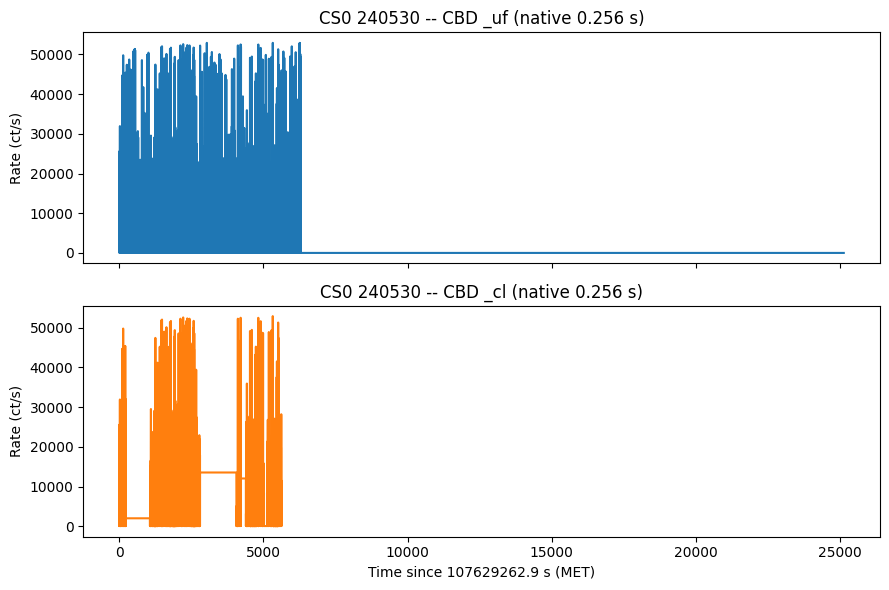

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

lc_uf = cbd_uf.to_lightcurve()
lc_cl = cbd_cl.to_lightcurve()

axes[0].step(lc_uf.lo_edges - cbd_uf.time_range[0], lc_uf.rates, where='post')
axes[0].set_title(f'{DETECTOR} {OBS_ID} -- CBD _uf (native 0.256 s)')
axes[0].set_ylabel('Rate (ct/s)')

axes[1].step(lc_cl.lo_edges - cbd_cl.time_range[0], lc_cl.rates, where='post', color='C1')
axes[1].set_title(f'{DETECTOR} {OBS_ID} -- CBD _cl (native 0.256 s)')
axes[1].set_xlabel(f'Time since {cbd_uf.time_range[0]:.1f} s (MET)')
axes[1].set_ylabel('Rate (ct/s)')

fig.tight_layout()
plt.show()

Even at native resolution, the `_cl` gaps are visible as blank stretches; the
`_uf` panel is denser but noisier and includes the intervals `_cl` removes.

## Rebinning

`Phaii.rebin_time` accepts any gdt-core binned-data rebinning function.
`combine_by_factor` merges a fixed number of consecutive bins and conserves
the total counts -- and, because gdt-core only rebins within a contiguous
run of bins, it never bridges a real gap.

**A caveat this surfaces in practice**: a handful of real bins arrive only
0.255 s after the previous one -- 1 ms short of the nominal 0.256 s
`TIMEDEL` (this is exactly what `BurstCubeCBD.blended` flags, per archive
caveat #9). The official caveat also states that CBD data blending is
*"filtered out in the archive clean files"*. What we measure here is
narrower than that: the `dt < TIMEDEL` test below flags 53 of this `_cl`
file's 12576 rows as arriving 1 ms short of the nominal cadence. Whether
that 1 ms shortfall is the same packet-cadence blending the caveat
describes, or something else `_cl` was never meant to remove, is not
something we can determine from this file alone -- we report the
measurement, not a verdict on the archive's filtering.
Under the `TIMEPIXR=1` bin-end convention, that makes the
*derived* start of that bin land 1 ms **before** the previous bin's end --
a real, if tiny, overlap, not a gap. gdt-core's rebinning refuses to merge
genuinely overlapping bins, so rebinning straight across one of these raises
rather than silently doing something undefined:

In [7]:
try:
    cbd_cl.rebin_time(combine_by_factor, 40)
except ValueError as err:
    print(f'{cbd_cl.blended.sum()} of {cbd_cl.data.size[0]} bins in this file are flagged `blended`')
    print(f'rebin_time raised: {err}')

In practice this means: rebin (and plot) a specific time window you care
about, rather than an entire raw day at once -- which is normal usage
anyway. Here we pick a clean window between two flagged bins:

window has 92 bins, 0 flagged blended: True
92 bins -> 22 bins after rebinning by a factor of 4
total counts conserved: 27500 -> 26538


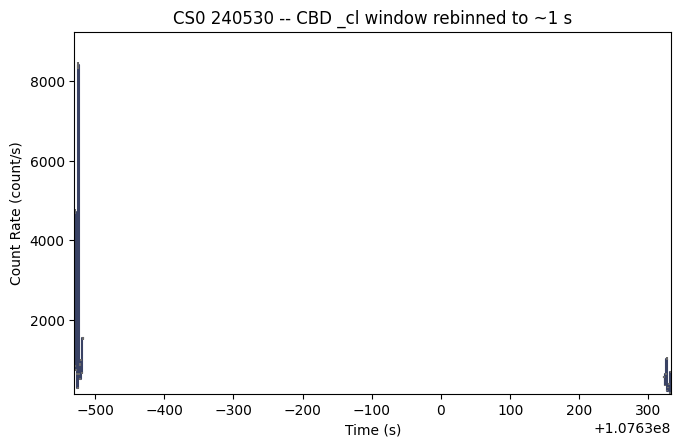

In [8]:
blended_idx = np.flatnonzero(cbd_cl.blended)
lo = cbd_cl.data.tstart[blended_idx[3] + 1]
hi = cbd_cl.data.tstart[blended_idx[4] - 1]
window = cbd_cl.slice_time([(lo, hi)])
print(f'window has {window.data.size[0]} bins, 0 flagged blended: {window.blended is None}')

rebinned = window.rebin_time(combine_by_factor, 4)  # 0.256 s -> ~1.024 s
print(f'{window.data.size[0]} bins -> {rebinned.data.size[0]} bins after rebinning by a factor of 4')
print(f'total counts conserved: {window.data.counts.sum()} -> {rebinned.data.counts.sum()}')

lcplot = Lightcurve(data=rebinned.to_lightcurve())
plt.title(f'{DETECTOR} {OBS_ID} -- CBD _cl window rebinned to ~1 s')
plt.show()

## Count spectra

Integrating over time instead of energy, with `to_spectrum()`, gives an
`EnergyBins` object -- the 16-channel CBD count spectrum.

/usr/local/lib/python3.11/dist-packages/gdt/core/plot/spectrum.py:154: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  self._ax.set_xlim(data.range)


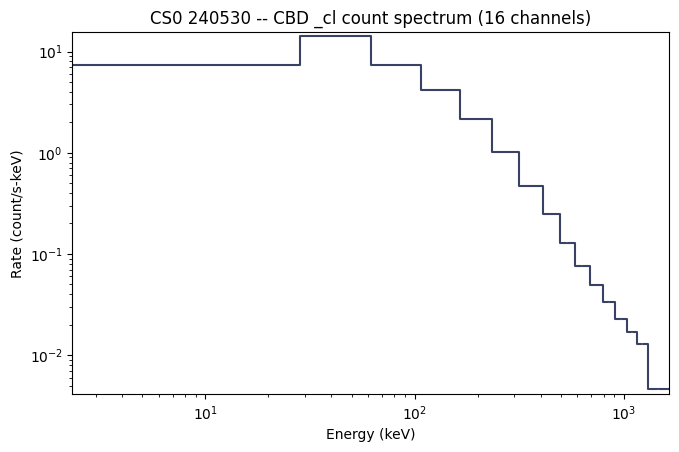

In [9]:
spectrum = cbd_cl.to_spectrum()
specplot = Spectrum(data=spectrum)
plt.title(f'{DETECTOR} {OBS_ID} -- CBD _cl count spectrum (16 channels)')
plt.show()

## TTE: unbinned events, and a header caveat that is **not** in the official document

TTE gives every photon's arrival time and 1024-channel pulse height.

Its `EVENTS` header `TSTART`/`TSTOP` cannot be trusted -- and this is **not**
a quirk of this one file, and **not** described anywhere in the official
archive caveats document. It affects **every** one of the archive's 28 TTE
files (7 days x 4 detectors), verified by reading all 28:

* all 28 store `TSTART`/`TSTOP` as FITS *strings* rather than numbers, and in
  all 28 `TSTOP - TSTART` disagrees with the file's own `ONTIME`;
* 16 of the 28 (days 240530, 240602, 240813, 240815) additionally have
  `TSTOP < TSTART`, which makes `TELAPSE`/`EXPOSURE` negative and leaves the
  primary header's `DATE-END` *earlier* than its `DATE-OBS`;
* the other 12 (days 240628, 240629, 240814) have `TSTOP > TSTART`, but the
  span still disagrees with `ONTIME`.

What *is* reliable: the `STDGTI` extension's `START`/`STOP` reproduce the
span of the actual event times **exactly** (0.000 s) in all 28 files, and
`ONTIME` agrees with that span to <= 0.7 ms. That is why `BurstCubeTTE.open()`
ignores `TSTART`/`TSTOP` entirely, derives the time range from `STDGTI` and
the events instead, and raises a `UserWarning` so the problem isn't silent.

The official caveats document's caveat #4 is about how few TTE files were
ever downlinked (34 short commissioning/validation windows, mission-wide) and
caveat #5 is about a 2024-08-15 timeline-alignment issue -- neither one
mentions these header keywords. See the README's *TTE TSTART/TSTOP are
unusable in every file* section for the full per-day table; it is not
reproduced here.

In [10]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    tte = BurstCubeTTE.open(tte_path)
    for w in caught:
        print(f'{w.category.__name__}: {w.message}')

print(tte)
print(f'{tte.data.size} events, energy range {tte.energy_range} keV')

<BurstCubeTTE: bc240530cs0_tte_uf.evt.gz;
 time range (np.float64(107629263.534), np.float64(107629558.606));
 energy range (16.219999313354492, 1429.68994140625)>
6364 events, energy range (16.219999313354492, 1429.68994140625) keV


## Binning TTE

`to_phaii()` bins the event list in time using any gdt-core unbinned-data
binning function, such as `bin_by_time` for a fixed bin width -- here, the
same 0.256 s as native CBD.

6364 events -> 6364 total binned counts (must match exactly) in 1153 bins


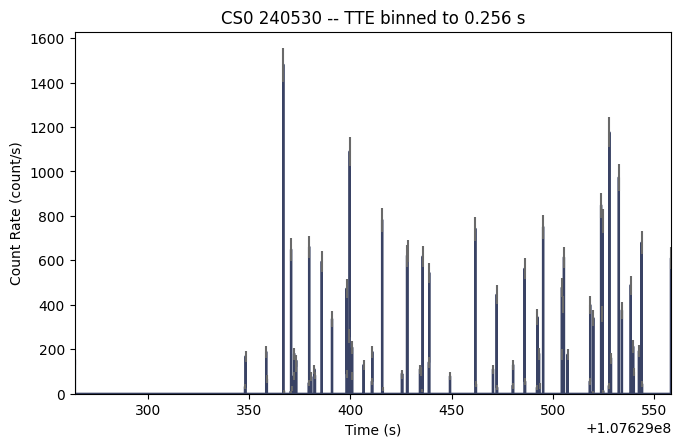

In [11]:
from gdt.core.phaii import Phaii

tte_phaii = tte.to_phaii(bin_by_time, 0.256, phaii_class=Phaii)
print(f'{tte.data.size} events -> {tte_phaii.data.counts.sum():.0f} total binned counts '
     f'(must match exactly) in {tte_phaii.data.size[0]} bins')

lcplot = Lightcurve(data=tte_phaii.to_lightcurve())
plt.title(f'{DETECTOR} {OBS_ID} -- TTE binned to 0.256 s')
plt.show()

## TTE vs CBD: day 240814, detector `CS0`

The rest of this notebook uses **2024-05-30**. This section switches to a
different one of the 7 TTE days, **2024-08-14** (`240814`), still detector
`CS0`, because that day has a long stretch where CBD and TTE can be compared
directly. Only the **cleaned** (`_cl`) CBD is used here.

In [12]:
TTE_DAY = '240814'

day_download_dir = Path(data_path) / 'burstcube' / TTE_DAY
day_download_dir.mkdir(parents=True, exist_ok=True)

day_finder = BurstCubeObsFinder()
day_finder.cd(TTE_DAY)

day_cbd_path, = day_finder.get_cbd(day_download_dir, detectors=DETECTOR, variant='cl', verbose=False)
day_tte_path, = day_finder.get_tte(day_download_dir, detectors=DETECTOR, verbose=False)

day_cbd = BurstCubeCBD.open(day_cbd_path)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    day_tte = BurstCubeTTE.open(day_tte_path)
    for w in caught:
        print(f'{w.category.__name__}: {w.message}')

day_t0, day_t1 = day_tte.time_range
print(f'{TTE_DAY} {DETECTOR} TTE: {day_tte.data.size} events, '
     f'MET {day_t0:.3f} to {day_t1:.3f} ({day_t1 - day_t0:.2f} s)')
print(f'{TTE_DAY} {DETECTOR} CBD _cl: {day_cbd.data.size[0]} bins')

240814 CS0 TTE: 11945 events, MET 114214208.408 to 114214432.668 (224.26 s)
240814 CS0 CBD _cl: 44383 bins


### Step 1: TTE binned in time, against CBD

CBD and TTE are not two instruments. They are the same detector and the same
event stream, written out two ways: CBD is binned on board into 16 channels
at 0.256 s, TTE is written event by event. So CBD is the reference for what
TTE should have contained.

To compare them, bin TTE on **CBD's own bin edges** with `bin_by_edges`,
rather than making a fresh uniform 0.256 s grid. A fresh grid is anchored on
the first event and does not line up with CBD's boundaries, so every one of
its bins straddles two CBD bins and neither the plot nor any ratio compares
like with like.

TTE does not cover its span continuously: it arrives in short recording
blocks separated by gaps of comparable length, and over a gap its binned
rate is exactly zero while CBD keeps counting at its normal rate. That is a
property of the archive, not of the sky -- see the **TTE gaps** caveat in the
README for the measurement behind it, and `examples/tte_gaps_vs_cbd.py` for
a standalone script that plots it.

`BurstCubeTTE.recording_blocks()` returns those blocks as a `Gti`, and
`gti.complement()` turns them into the gaps. Every later step needs the
blocks, because a rate computed over an interval that spans a gap is diluted
by the gap's duration.

94 TTE recording blocks, 97.1 s of live time in a 224.3 s span (a factor of 2.31)
CBD _cl: 866 bins inside the TTE span


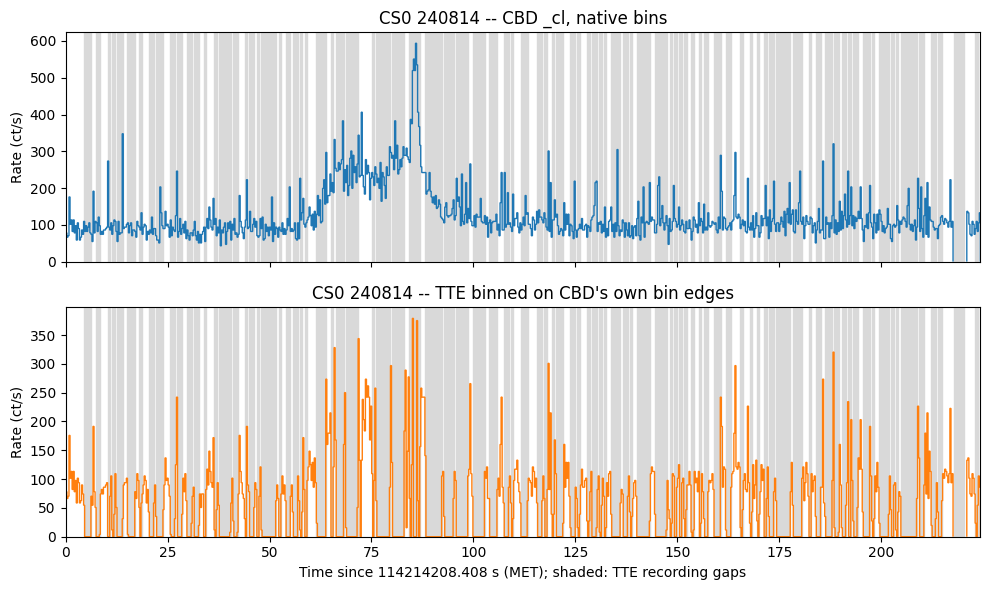

In [13]:
blocks = day_tte.recording_blocks()   # default 0.5 s gap threshold
gaps = complement(blocks, day_t0, day_t1)

live_s = sum(stop - start for start, stop in blocks.as_list())
span_s = day_t1 - day_t0
print(f'{blocks.num_intervals} TTE recording blocks, {live_s:.1f} s of live '
     f'time in a {span_s:.1f} s span (a factor of {span_s / live_s:.2f})')

day_cbd_span = day_cbd.slice_time([(day_t0, day_t1)])
cbd_data = day_cbd_span.data
cbd_edges = np.append(cbd_data.tstart, cbd_data.tstop[-1])
print(f'CBD _cl: {cbd_data.size[0]} bins inside the TTE span')

# the same bins for both, so the panels can be read against each other
day_tte_phaii = day_tte.to_phaii(bin_by_edges, cbd_edges, phaii_class=Phaii)

# _cl drops intervals, so two of CBD's own bin boundaries are not contiguous
# and the bins bridging them are wider than the rest; blank those out
bridges_a_cbd_gap = np.append(cbd_data.tstart[1:] - cbd_data.tstop[:-1] > 1e-9, False)
blank = lambda counts: np.where(bridges_a_cbd_gap, np.nan, counts / cbd_data.exposure)

cbd_rates = blank(cbd_data.counts.sum(axis=1))
tte_rates = blank(day_tte_phaii.data.counts.sum(axis=1))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, rates, color, title in [
        (axes[0], cbd_rates, 'C0', 'CBD _cl, native bins'),
        (axes[1], tte_rates, 'C1', "TTE binned on CBD's own bin edges")]:
    for start, stop in gaps.as_list():
        ax.axvspan(start - day_t0, stop - day_t0, color='0.85', zorder=0)
    ax.stairs(rates, cbd_edges - day_t0, color=color)
    ax.set_title(f'{DETECTOR} {TTE_DAY} -- {title}')
    ax.set_ylabel('Rate (ct/s)')

axes[1].set_xlabel(f'Time since {day_t0:.3f} s (MET); shaded: TTE recording gaps')
axes[0].set_xlim(0, span_s)

fig.tight_layout()
plt.show()

Every stretch where the TTE panel drops to zero is a shaded gap, and CBD
runs straight through all of them. So the comparison below is made bin by
bin, over intervals that lie entirely inside a recording block.

### Step 2: compared in energy

Use only the CBD bins that lie *entirely inside* a TTE recording block (the
same blocks found in Step 1), so both sides cover identical intervals and no
rate scaling is needed.

In [14]:
cbd_tstart = day_cbd.data.tstart
cbd_tstop = day_cbd.data.tstop

matched_mask = np.zeros(cbd_tstart.size, dtype=bool)
for block_start, block_stop in blocks.as_list():
    matched_mask |= (cbd_tstart >= block_start) & (cbd_tstop <= block_stop)
matched_idx = np.flatnonzero(matched_mask)
matched_exposure = day_cbd.data.exposure[matched_idx].sum()

print(f'{blocks.num_intervals} TTE blocks -> {matched_idx.size} matched CBD '
     f'bins, {matched_exposure:.2f} s')

94 TTE blocks -> 284 matched CBD bins, 72.70 s


Regroup TTE's 1024 native channels to CBD's 16 using the CALDB `reb16`
scheme directly (`gdt.missions.burstcube.caldb.rebin('CS0', 16)`), counting
each event into the channel whose `[chan_min, chan_max]` contains its `PHA`.
This mapping is exact: the CALDB `reb16` group boundaries reproduce the
`eb16` energy edges for this detector, so TTE group *i* and CBD channel *i*
span identical energies -- no interpolation or approximation involved.
Restrict TTE events to the exact union of the matched CBD bin windows, so
both sides cover precisely the same intervals.

In [15]:
matched_cbd_counts = day_cbd.data.counts[matched_idx].sum(axis=0)

reb16 = caldb.rebin(DETECTOR, 16)
eb16 = caldb.ebounds(DETECTOR, 16)

matched_starts = cbd_tstart[matched_idx]
matched_stops = cbd_tstop[matched_idx]
tte_in_matched = np.zeros(day_tte.data.times.size, dtype=bool)
for bin_start, bin_stop in zip(matched_starts, matched_stops):
    tte_in_matched |= (day_tte.data.times >= bin_start) & (day_tte.data.times < bin_stop)

matched_pha = day_tte.data.channels[tte_in_matched]
matched_tte_counts = np.array([
    np.count_nonzero((matched_pha >= lo_ch) & (matched_pha <= hi_ch))
    for lo_ch, hi_ch in zip(reb16.chan_min, reb16.chan_max)
])

cbd_total, tte_total = matched_cbd_counts.sum(), matched_tte_counts.sum()
ratio_total = cbd_total / tte_total
ratio_err = ratio_total * np.sqrt(1 / cbd_total + 1 / tte_total)

print(f'total: CBD {cbd_total}   TTE {tte_total}   '
     f'ratio {ratio_total:.4f} +/- {ratio_err:.4f}\n')
print(f'{"chan":>4} {"E range (keV)":>16} {"CBD":>8} {"TTE":>8} {"ratio":>7}')
for i in range(16):
    erange = f'{eb16.low_edges()[i]:.1f}-{eb16.high_edges()[i]:.1f}'
    if matched_tte_counts[i] > 0:
        r = f'{matched_cbd_counts[i] / matched_tte_counts[i]:.2f}'
    else:
        r = 'n/a'
    print(f'{i:4d} {erange:>16} {matched_cbd_counts[i]:8d} {matched_tte_counts[i]:8d} {r:>7}')

total: CBD 8860   TTE 8600   ratio 1.0302 +/- 0.0156

chan    E range (keV)      CBD      TTE   ratio
   0         0.0-28.5        0        0     n/a
   1        28.5-62.2       13       13    1.00
   2       62.2-106.9     3041     2928    1.04
   3      106.9-165.6     2471     2396    1.03
   4      165.6-233.9     1239     1197    1.04
   5      233.9-316.5      641      628    1.02
   6      316.5-410.8      386      384    1.01
   7      410.8-494.5      330      326    1.01
   8      494.5-585.1      150      148    1.01
   9      585.1-686.0      120      118    1.02
  10      686.0-792.3      108      104    1.04
  11      792.3-907.6       78       78    1.00
  12     907.6-1030.3       64       63    1.02
  13    1030.3-1160.7       81       82    0.99
  14    1160.7-1298.8       65       63    1.03
  15    1298.8-1648.5       73       72    1.01


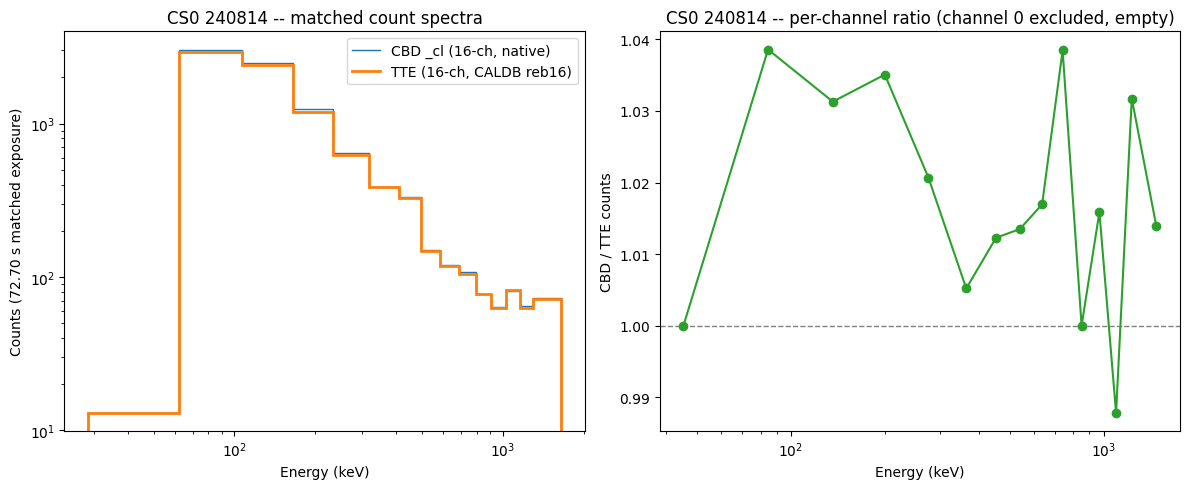

In [16]:
edges16 = np.append(eb16.low_edges(), eb16.high_edges()[-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].stairs(matched_cbd_counts, edges16, label='CBD _cl (16-ch, native)', color='C0')
axes[0].stairs(matched_tte_counts, edges16, label='TTE (16-ch, CALDB reb16)',
              color='C1', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Energy (keV)')
axes[0].set_ylabel(f'Counts ({matched_exposure:.2f} s matched exposure)')
axes[0].set_title(f'{DETECTOR} {TTE_DAY} -- matched count spectra')
axes[0].legend()

chan_mid = 0.5 * (edges16[:-1] + edges16[1:])
with np.errstate(divide='ignore', invalid='ignore'):
    per_chan_ratio = matched_cbd_counts / matched_tte_counts
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].plot(chan_mid[1:], per_chan_ratio[1:], 'o-', color='C2')
axes[1].set_xscale('log')
axes[1].set_xlabel('Energy (keV)')
axes[1].set_ylabel('CBD / TTE counts')
axes[1].set_title(f'{DETECTOR} {TTE_DAY} -- per-channel ratio (channel 0 excluded, empty)')

fig.tight_layout()
plt.show()

With the intervals matched exactly, the two formats agree to within a few
percent across the whole spectrum, with no systematic trend with energy.
(The residual is not spread evenly over time: it is concentrated in the
brightest bins, where TTE drops events, and vanishes below 200 ct/s. The
README's **TTE gaps** caveat has that breakdown.)

Channel 0 (below ~28.5 keV) is empty in both: by August 2024 the
per-detector low-energy trigger thresholds had already been raised to
roughly 100 keV (the mid-mission change covered in the next section), so
channel 0 sits below the detector's threshold.

### The same events at TTE's native resolution

Everything above puts TTE on CBD's 16-channel grid, which is the right thing
to do for a comparison but throws away most of what TTE records. Plotting
the same events at their native 1024 channels
(`caldb.ebounds('CS0', 1024)`) shows what that grid costs.

Both are shown as counts **per keV**, since the two channel grids have wildly
different widths -- a CBD channel here is 34-350 keV wide, a TTE channel
1.0-1.7 keV -- and raw counts per channel would say more about the binning
than about the spectrum. On this normalisation a CBD channel is just the
average of the TTE curve across it.

In [17]:
eb1024 = caldb.ebounds(DETECTOR, 1024)
lo1024 = np.asarray(eb1024.low_edges())
hi1024 = np.asarray(eb1024.high_edges())
edges1024 = np.append(lo1024, hi1024[-1])

native_counts = np.bincount(matched_pha, minlength=1024)
native_density = native_counts / (hi1024 - lo1024)
lo16 = np.asarray(eb16.low_edges())
hi16 = np.asarray(eb16.high_edges())
cbd_density = matched_cbd_counts / (hi16 - lo16)

occupied = np.flatnonzero(native_counts)
peak = native_density.argmax()
# the low-energy edge: the first channel reaching half the peak density
turn_on = np.flatnonzero(native_density >= 0.5 * native_density[peak])[0]

print(f'{matched_pha.size} events over {occupied.size} of the 1024 channels, '
     f'{lo1024[occupied[0]]:.1f} to {hi1024[occupied[-1]]:.1f} keV')
print(f'threshold turn-on (half peak density) at {lo1024[turn_on]:.1f} keV; '
     f'only {native_counts[:turn_on].sum()} events lie below it')
print(f'peak density {native_density[peak]:.0f} counts/keV at {lo1024[peak]:.1f} keV')

which = np.searchsorted(hi16, lo1024[turn_on])
print(f'\nThat turn-on falls inside CBD channel {which}, which spans '
     f'{lo16[which]:.1f}-{hi16[which]:.1f} keV '
     f'({hi16[which] - lo16[which]:.1f} keV wide) '
     f'at a flat {cbd_density[which]:.1f} counts/keV.')

8600 events over 672 of the 1024 channels, 37.7 to 1451.6 keV
threshold turn-on (half peak density) at 77.6 keV; only 73 events lie below it
peak density 125 counts/keV at 79.2 keV

That turn-on falls inside CBD channel 2, which spans 62.2-106.9 keV (44.6 keV wide) at a flat 68.1 counts/keV.


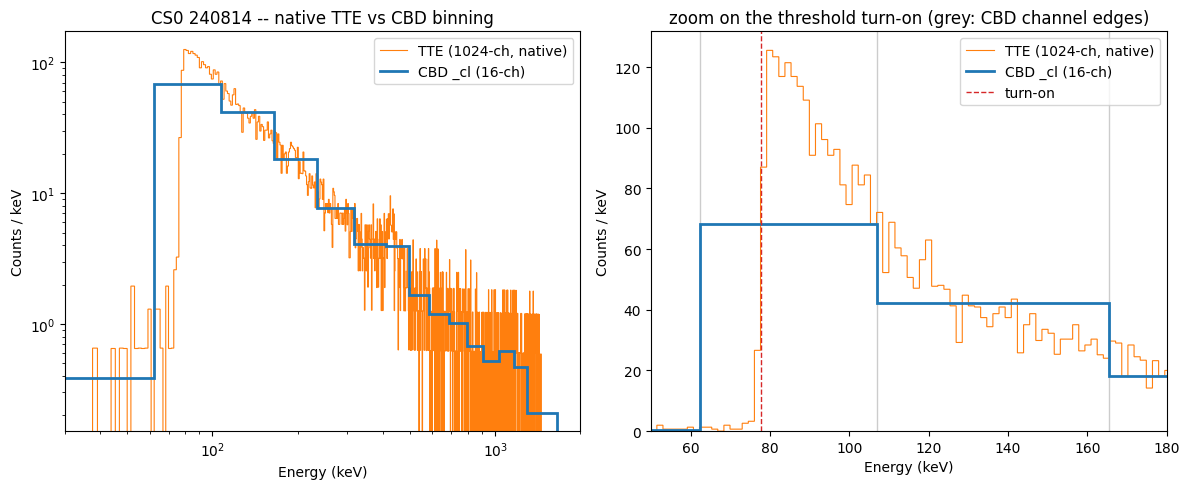

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax in axes:
    ax.stairs(native_density, edges1024, color='C1', linewidth=0.8,
             label='TTE (1024-ch, native)')
    ax.stairs(cbd_density, edges16, color='C0', linewidth=2,
             label='CBD _cl (16-ch)')
    ax.set_xlabel('Energy (keV)')
    ax.set_ylabel('Counts / keV')
    ax.legend()

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(30, 2000)
axes[0].set_title(f'{DETECTOR} {TTE_DAY} -- native TTE vs CBD binning')

for edge in edges16[1:5]:
    axes[1].axvline(edge, color='0.8', linewidth=1, zorder=0)
axes[1].axvline(lo1024[turn_on], color='C3', linestyle='--', linewidth=1,
               label='turn-on')
axes[1].set_xlim(50, 180)
axes[1].set_title('zoom on the threshold turn-on (grey: CBD channel edges)')
axes[1].legend()

fig.tight_layout()
plt.show()

The CBD steps track the TTE curve where the spectrum is smooth -- which is
the check that the two really are the same events -- and flatten it
everywhere it is not.

The threshold turn-on is the clearest case. At 1024 channels it is almost a
step: nothing below ~76 keV, then the peak density two channels later. That
is archive caveat #7's raised low-energy threshold, measured. In CBD it is
invisible, because the whole turn-on happens **inside** one 44.7 keV-wide
channel, which reports a single flat number across it. CBD can tell you the
threshold is somewhere between 62 and 107 keV; it cannot tell you where, or
how sharp.

The practical rule: use TTE's native channels for anything about the
detector's own response -- threshold, resolution, line features -- and
regroup to 16 or 64 only to compare against CBD, or to fold against a
response matrix in that binning.

## Caveat: the mid-mission energy threshold change

Per archive caveat #7, the per-detector low-energy trigger thresholds were
raised roughly mid-mission (from ~21-30 keV to ~100 keV) to suppress a
non-Poissonian noise component. `DETECTOR_HK2`'s `PEAK_THRES`/`BASE_THRES`
columns (60 s cadence, one value per detector) are how that shows up in the
housekeeping data; a single day's file only shows one side of that change,
so comparing an early-mission and late-mission day's HK is what actually
demonstrates it.

In [19]:
hk = BurstCubeHK.open(hk_path)
peak = hk.peak_threshold(DETECTOR)
print(f'{OBS_ID} {DETECTOR} PEAK_THRES (mV), first/last HK2 row: {peak[0]:.2f} / {peak[-1]:.2f}')
print(f'DET_ENABLED (all 4 detectors), first HK1 row: {hk.det_enabled()[0]}')

240530 CS0 PEAK_THRES (mV), first/last HK2 row: 6.00 / 6.00
DET_ENABLED (all 4 detectors), first HK1 row: [0 0 0 0]


## Summary

* CBD is pre-binned (16 channels); TTE is unbinned (1024 channels, folds to
  64 to match the full response binning).
* `_uf` keeps everything; `_cl` removes bad/unphysical intervals. Use `_cl`
  unless you have a specific reason not to.
* Every TTE file's `EVENTS` header timing keywords are broken; the reader
  works around it and tells you so.
* TTE covers its span in short recording blocks with gaps in between, and
  reads exactly zero across a gap while the detector is still counting.
  Find the blocks before computing any TTE rate.
* Matched interval for interval, CBD and TTE agree to a few percent with no
  trend in energy.
* Detector thresholds changed mid-mission; `DETECTOR_HK2` is where to look.